# What AI Still Cannot Do
### *Modern Strain Gage Technology* — Companion Notebook

Machine learning models perform well within the conditions they were trained on. Beyond those conditions, they fail — sometimes gracefully, more often silently.

**Companion notebook to Chapter 64 — What AI Still Cannot Do.**

This notebook demonstrates three failure modes every engineer should understand before deploying a data-driven model in a structural monitoring application — and a set of practical guardrails that contain them.

1. **Extrapolation failure** — models cannot learn physics they have never seen; post-yield behavior is invisible to a model trained in the elastic regime  
2. **Silent distribution shift** — a model gives confident predictions on data from a different material, with no warning that it is outside its domain  
3. **Physics constraint violations** — an overfit model can produce predictions that violate known physical laws (negative stiffness, non-monotone response)  
4. **Guardrails** — three practical, post-hoc mitigations that require no retraining

In [1]:
# !pip install numpy matplotlib scikit-learn

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Figures are written to this directory. Do NOT change these paths or filenames —
# the book includes these exact files.
OUT_DIR = Path("../src/media/ch64")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Extrapolation Failure

Every supervised learning model is, at root, an interpolation engine. It finds patterns within the range of data it has seen and reproduces them. When you feed it inputs outside that range, it has nothing to draw on — and it does not know that.

For strain measurement, this failure mode is particularly dangerous. A model trained on a structure in its elastic regime will be utterly unprepared for post-yield behavior. The true stress–strain curve for aluminium 6061-T6 bends at ~276 MPa and saturates near 310 MPa. A model trained only on the straight elastic portion will predict a straight line — or something worse — regardless of how far past yield the material has gone.

Three model families are trained here on elastic-zone data only (0–3500 µε, yield begins at ~4006 µε). All three are then tested through and well past the yield point.

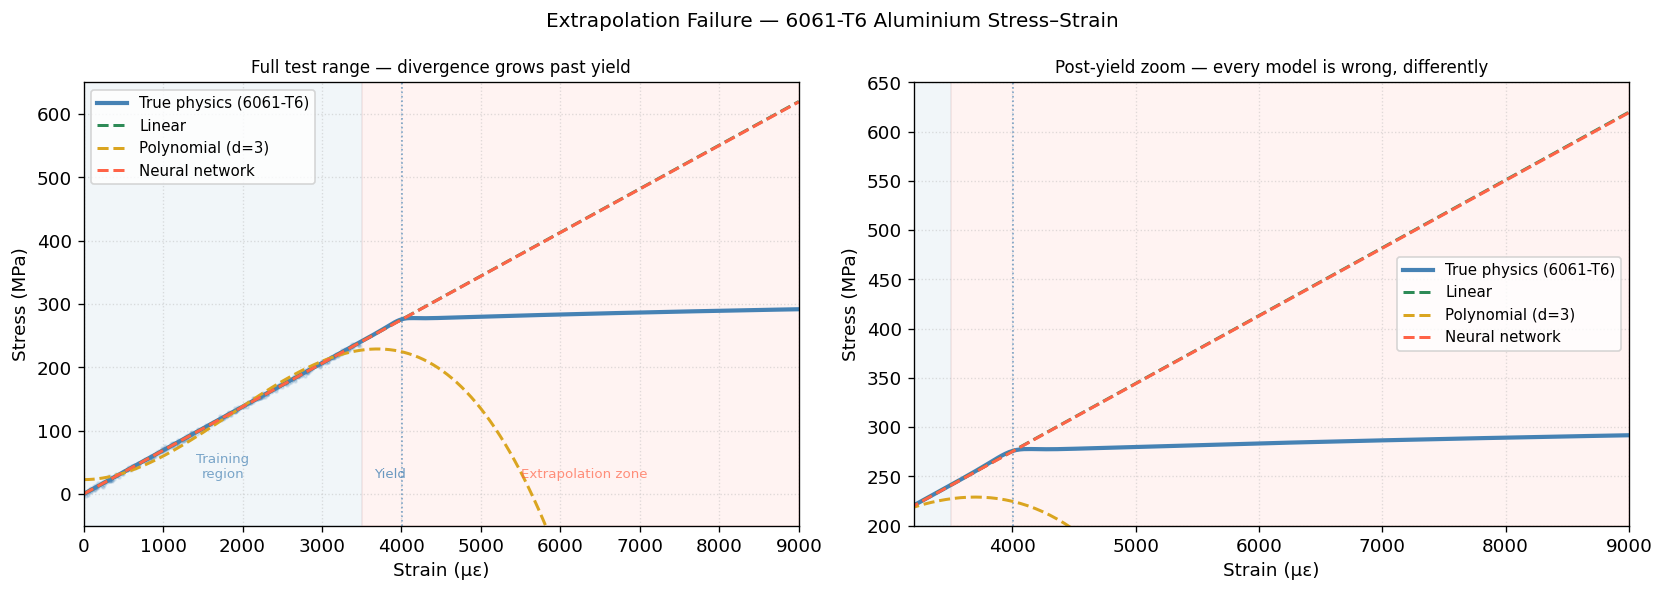

Model                    MAE in extrap. zone (MPa)  Failure mode
--------------------------------------------------------------------------------
Linear                                       148.9  overshoots — extrapolates linearly past yield plateau
Polynomial (d=3)                             759.7  curls wildly — high-degree terms amplify out-of-range
Neural network                               148.5  saturates — activation functions bound the output


In [2]:
# ── 1. Extrapolation Failure ──────────────────────────────────────────────────
# Physical constants for 6061-T6 aluminium (imports live in the top cell).
E_mpa     = 68900   # Young's modulus (MPa) — 68.9 GPa
sigma_y   = 276     # yield strength (MPa)
sigma_uts = 310     # ultimate tensile strength (MPa)
eps_y_ue  = sigma_y / (E_mpa * 1e-6)   # yield strain ≈ 4006 µε

# Shape parameters for the synthetic constitutive model (µε).
HARDENING_DECAY_UE = 8000   # how fast stress saturates toward the UTS
YIELD_BLEND_UE     = 150    # smooths the elastic → plastic transition

def al_stress(eps_ue):
    """Synthetic 6061-T6 stress (MPa) as a function of strain (µε).

    Linear-elastic below the yield strain, then a smoothly blended,
    exponentially saturating hardening branch approaching the UTS. Serves as
    the ground-truth "true physics" curve the fitted models are judged against.
    """
    sigma_e = E_mpa * 1e-6 * eps_ue
    excess  = np.maximum(0, eps_ue - eps_y_ue)
    sigma_h = sigma_y + (sigma_uts - sigma_y) * (1 - np.exp(-excess / HARDENING_DECAY_UE))
    t = 0.5 * (1 + np.tanh((eps_ue - eps_y_ue) / YIELD_BLEND_UE))
    return sigma_e * (1 - t) + sigma_h * t

np.random.seed(42)
eps_tr = np.random.uniform(0, 3500, 400)   # elastic zone only — below yield
sig_tr = al_stress(eps_tr) + np.random.normal(0, 2, 400)

lin  = LinearRegression().fit(eps_tr.reshape(-1, 1), sig_tr)
poly = Pipeline([('p', PolynomialFeatures(3)), ('r', LinearRegression())]).fit(
         eps_tr.reshape(-1, 1), sig_tr)
nn   = MLPRegressor(hidden_layer_sizes=(64, 32, 16), max_iter=3000,
                    random_state=0, alpha=0.01).fit(eps_tr.reshape(-1, 1), sig_tr)

eps_te = np.linspace(0, 9000, 300)
true   = al_stress(eps_te)
preds  = {
    'Linear':           lin.predict(eps_te.reshape(-1, 1)),
    'Polynomial (d=3)': poly.predict(eps_te.reshape(-1, 1)),
    'Neural network':   nn.predict(eps_te.reshape(-1, 1)),
}
colors = {'Linear': 'seagreen', 'Polynomial (d=3)': 'goldenrod', 'Neural network': 'tomato'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Extrapolation Failure — 6061-T6 Aluminium Stress–Strain', fontsize=12)

for ax, xlim, ylim, title in [
    (axes[0], (0, 9000),    (-50, 650),
     'Full test range — divergence grows past yield'),
    (axes[1], (3200, 9000), (200, 650),
     'Post-yield zoom — every model is wrong, differently'),
]:
    ax.axvspan(0,    3500, alpha=0.07, color='steelblue')
    ax.axvspan(3500, 9000, alpha=0.07, color='tomato')
    ax.plot(eps_te, true, 'steelblue', lw=2.5, label='True physics (6061-T6)')
    ax.axvline(eps_y_ue, color='steelblue', lw=1, ls=':', alpha=0.7)
    if ax is axes[0]:
        ax.text(3650, 25, 'Yield', fontsize=8, color='steelblue', alpha=0.8)
        ax.text(1750, 25, 'Training\nregion', ha='center', fontsize=8,
                color='steelblue', alpha=0.7)
        ax.text(6300, 25, 'Extrapolation zone', ha='center', fontsize=8,
                color='tomato', alpha=0.7)
        ax.scatter(eps_tr, sig_tr, s=3, alpha=0.15, color='steelblue')
    for name, pred in preds.items():
        ax.plot(eps_te, pred, color=colors[name], lw=1.8, ls='--', label=name)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel('Strain (µε)'); ax.set_ylabel('Stress (MPa)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig64_nb1_extrapolation_failure.png', bbox_inches='tight', dpi=150)
plt.show()

extrap = eps_te > 3500
failure_modes = {
    'Linear':           'overshoots — extrapolates linearly past yield plateau',
    'Polynomial (d=3)': 'curls wildly — high-degree terms amplify out-of-range',
    'Neural network':   'saturates — activation functions bound the output',
}
print(f"{'Model':22s}  {'MAE in extrap. zone (MPa)':>26}  {'Failure mode'}")
print('-' * 80)
for name, pred in preds.items():
    mae = np.abs(pred[extrap] - true[extrap]).mean()
    print(f"{name:22s}  {mae:>26.1f}  {failure_modes[name]}")

---
## 2 — Silent Distribution Shift

A model trained on one material knows that material. Deployed on a different material, it applies the first material's constitutive relationship to the second material's strain readings — and returns a number without complaint.

This is the *silent* part. The model does not throw an exception. It does not print a warning. It returns a von Mises stress estimate that looks exactly like any other output. An engineer who trusts it will make decisions based on systematically incorrect data.

The example uses a two-channel strain rosette on a biaxially loaded plate. The model learns to map (ε₁, ε₂) → von Mises stress from structural steel (E = 200 GPa, ν = 0.28). It is then applied to 6061-T6 aluminium (E = 69 GPa, ν = 0.33), where the strain-to-stress mapping is fundamentally different — different Young's modulus, different Poisson coupling, different scale of strains for any given load.

Validation — steel (in-distribution):     RMSE = 3.6 MPa
Aluminium  — shifted (out-of-distribution): RMSE = 161.4 MPa   (45.3× worse)

The model returned a prediction for every aluminium input.
No exception. No 'I do not know.' Just wrong answers, delivered with equal confidence.


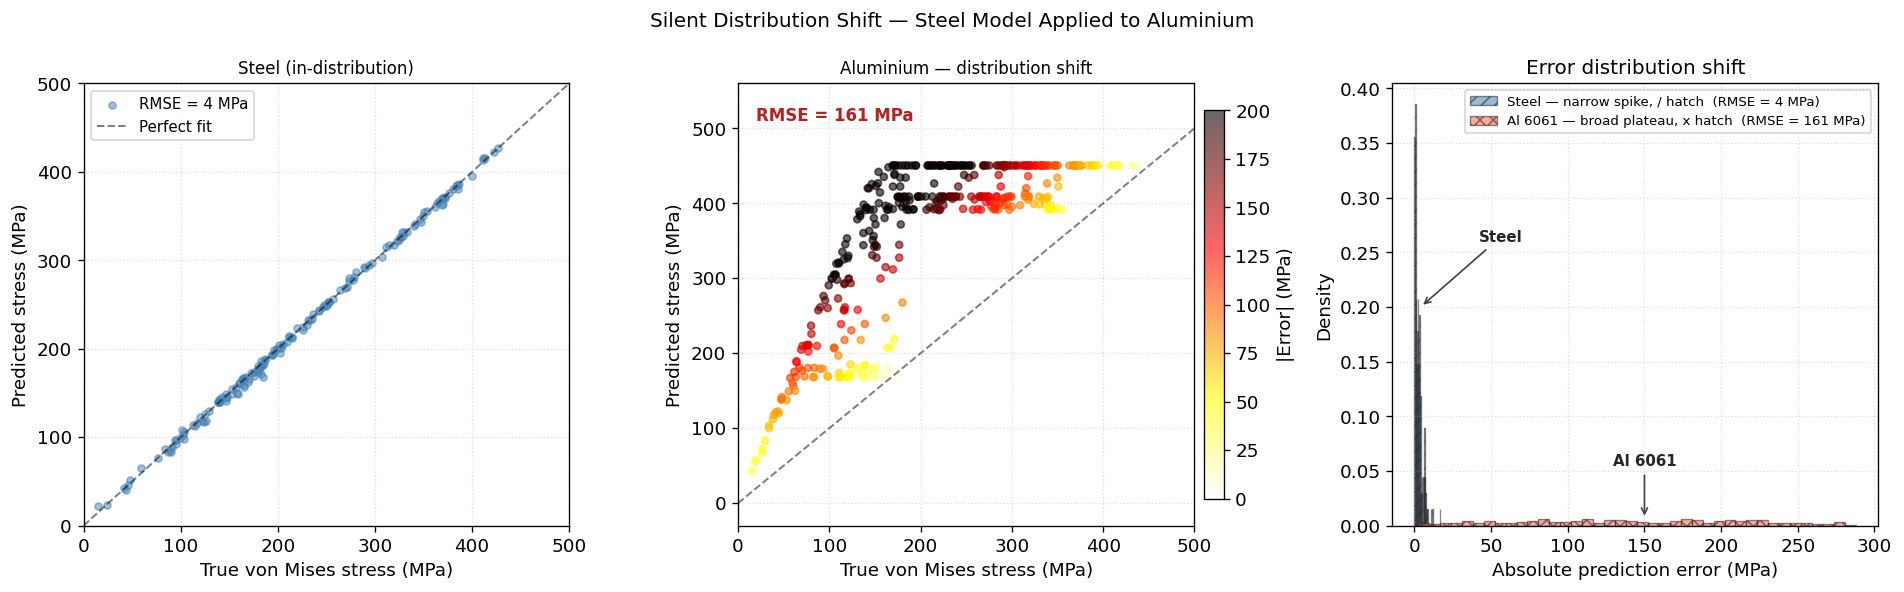

In [3]:
# ── 2. Silent Distribution Shift ─────────────────────────────────────────────
# A 2-channel strain rosette on a biaxially loaded plate.
# The model learns to map (ε₁, ε₂) → von Mises stress from structural steel data.
# It is then applied to 6061-T6 aluminium — different E, different ν, different mapping.
# No exception is raised. The outputs look like valid stress estimates. They are not.
# (Imports live in the top cell.)

def make_plate_data(E_gpa, nu, n, seed):
    """Synthetic biaxial plate data for one material (plane stress).

    Draws random principal stresses, converts them to the surface strains a
    rosette would report via the plane-stress Hooke's law
    ε₁ = (σ₁ − ν σ₂)/E and ε₂ = (σ₂ − ν σ₁)/E, and returns the strains in µε
    as features ``X`` with the von Mises stress (MPa) as target ``y``.

    Parameters
    ----------
    E_gpa : float  Young's modulus in GPa.
    nu    : float  Poisson's ratio.
    n     : int    Number of samples.
    seed  : int    Seed for this material's independent RNG stream.
    """
    rng = np.random.default_rng(seed)
    sigma1 = rng.uniform(10, 400, n)
    sigma2 = rng.uniform(-100, 200, n)
    E = E_gpa * 1e3   # MPa
    eps1 = (sigma1 - nu * sigma2) / E
    eps2 = (sigma2 - nu * sigma1) / E
    noise = rng.normal(0, 4e-6, (n, 2))
    X = (np.column_stack([eps1, eps2]) + noise) * 1e6   # µε
    y = np.sqrt(sigma1**2 - sigma1*sigma2 + sigma2**2)  # von Mises (MPa)
    return X, y

np.random.seed(0)
X_steel, y_steel = make_plate_data(200, 0.28, 800, seed=0)
X_alum,  y_alum  = make_plate_data( 69, 0.33, 400, seed=1)

X_tr, X_val, y_tr, y_val = train_test_split(X_steel, y_steel, test_size=0.2, random_state=0)
model_ds = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=0)
model_ds.fit(X_tr, y_tr)

val_pred  = model_ds.predict(X_val)
alum_pred = model_ds.predict(X_alum)
val_rmse  = np.sqrt(np.mean((val_pred - y_val)**2))
alum_rmse = np.sqrt(np.mean((alum_pred - y_alum)**2))

print(f"Validation — steel (in-distribution):     RMSE = {val_rmse:.1f} MPa")
print(f"Aluminium  — shifted (out-of-distribution): RMSE = {alum_rmse:.1f} MPa   "
      f"({alum_rmse/val_rmse:.1f}× worse)")
print()
print("The model returned a prediction for every aluminium input.")
print("No exception. No 'I do not know.' Just wrong answers, delivered with equal confidence.")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Silent Distribution Shift — Steel Model Applied to Aluminium', fontsize=12)

lim = [0, 500]

# Panel 1: steel — solid colour; errors are tiny and uniform, no need for heat map
ax = axes[0]
ax.scatter(y_val, val_pred, color='steelblue', s=18, alpha=0.5,
           label=f'RMSE = {val_rmse:.0f} MPa')
ax.plot(lim, lim, 'k--', lw=1.2, alpha=0.5, label='Perfect fit')
ax.set_xlabel('True von Mises stress (MPa)')
ax.set_ylabel('Predicted stress (MPa)')
ax.set_title('Steel (in-distribution)', fontsize=10)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

# Panel 2: aluminium — colour encodes error to show heterogeneous failure
ax = axes[1]
alum_err = np.abs(alum_pred - y_alum)
sc = ax.scatter(y_alum, alum_pred, c=alum_err, cmap='hot_r', s=18, alpha=0.6,
                vmin=0, vmax=200)
ax.plot(lim, lim, 'k--', lw=1.2, alpha=0.5, label='Perfect fit')
ax.set_xlabel('True von Mises stress (MPa)')
ax.set_ylabel('Predicted stress (MPa)')
ax.set_title('Aluminium — distribution shift', fontsize=10)
ax.set_xlim(lim); ax.set_ylim([-30, 560])
ax.text(20, 510, f'RMSE = {alum_rmse:.0f} MPa', fontsize=10, color='firebrick', fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.4)
plt.colorbar(sc, ax=axes[1], label='|Error| (MPa)', fraction=0.04, pad=0.02)

# Panel 3: error histograms. The two distributions overlap, so each one is
# hatched and labelled in place — colour alone would vanish in a black-and-
# white printing of the book.
err_steel = np.abs(val_pred  - y_val)
err_alum  = np.abs(alum_pred - y_alum)
axes[2].hist(err_steel, bins=40, density=True, facecolor='steelblue', alpha=0.55,
             hatch='///', edgecolor='0.15', linewidth=0.8,
             label=f'Steel — narrow spike, / hatch  (RMSE = {val_rmse:.0f} MPa)')
axes[2].hist(err_alum, bins=40, density=True, facecolor='tomato', alpha=0.55,
             hatch='xxx', edgecolor='0.15', linewidth=0.8,
             label=f'Al 6061 — broad plateau, x hatch  (RMSE = {alum_rmse:.0f} MPa)')
axes[2].set_xlabel('Absolute prediction error (MPa)')
axes[2].set_ylabel('Density')
axes[2].set_title('Error distribution shift')
axes[2].annotate('Steel', xy=(4, 0.20), xytext=(42, 0.26), fontsize=9,
                 color='0.15', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='0.25', lw=1.0))
axes[2].annotate('Al 6061', xy=(150, 0.006), xytext=(150, 0.055), fontsize=9,
                 color='0.15', fontweight='bold', ha='center',
                 arrowprops=dict(arrowstyle='->', color='0.25', lw=1.0))
axes[2].legend(fontsize=8); axes[2].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig64_nb2_distribution_shift.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 3 — Physics Constraint Violations

A supervised model learns correlations in data. It does not learn laws of physics — it has no representation of them unless you explicitly encode them. When the model's learned function violates a physical constraint, the model does not know. It cannot know. There is no internal alarm.

For a linear elastic specimen under monotone loading, the structural stiffness dF/dε must always be positive. This is not a soft preference; it is a consequence of thermodynamic stability. A structure with negative stiffness would accelerate under its own load and spontaneously collapse.

The demonstration below uses 18 training points with realistic sensor noise — a sparse data budget typical of prototype tests. A degree-9 polynomial regression has enough free parameters to chase every dip and rise in the noisy data, but no mechanism to enforce physical consistency. The derivative of the fitted curve goes negative in several regions, producing a result that is numerically plausible but physically impossible.

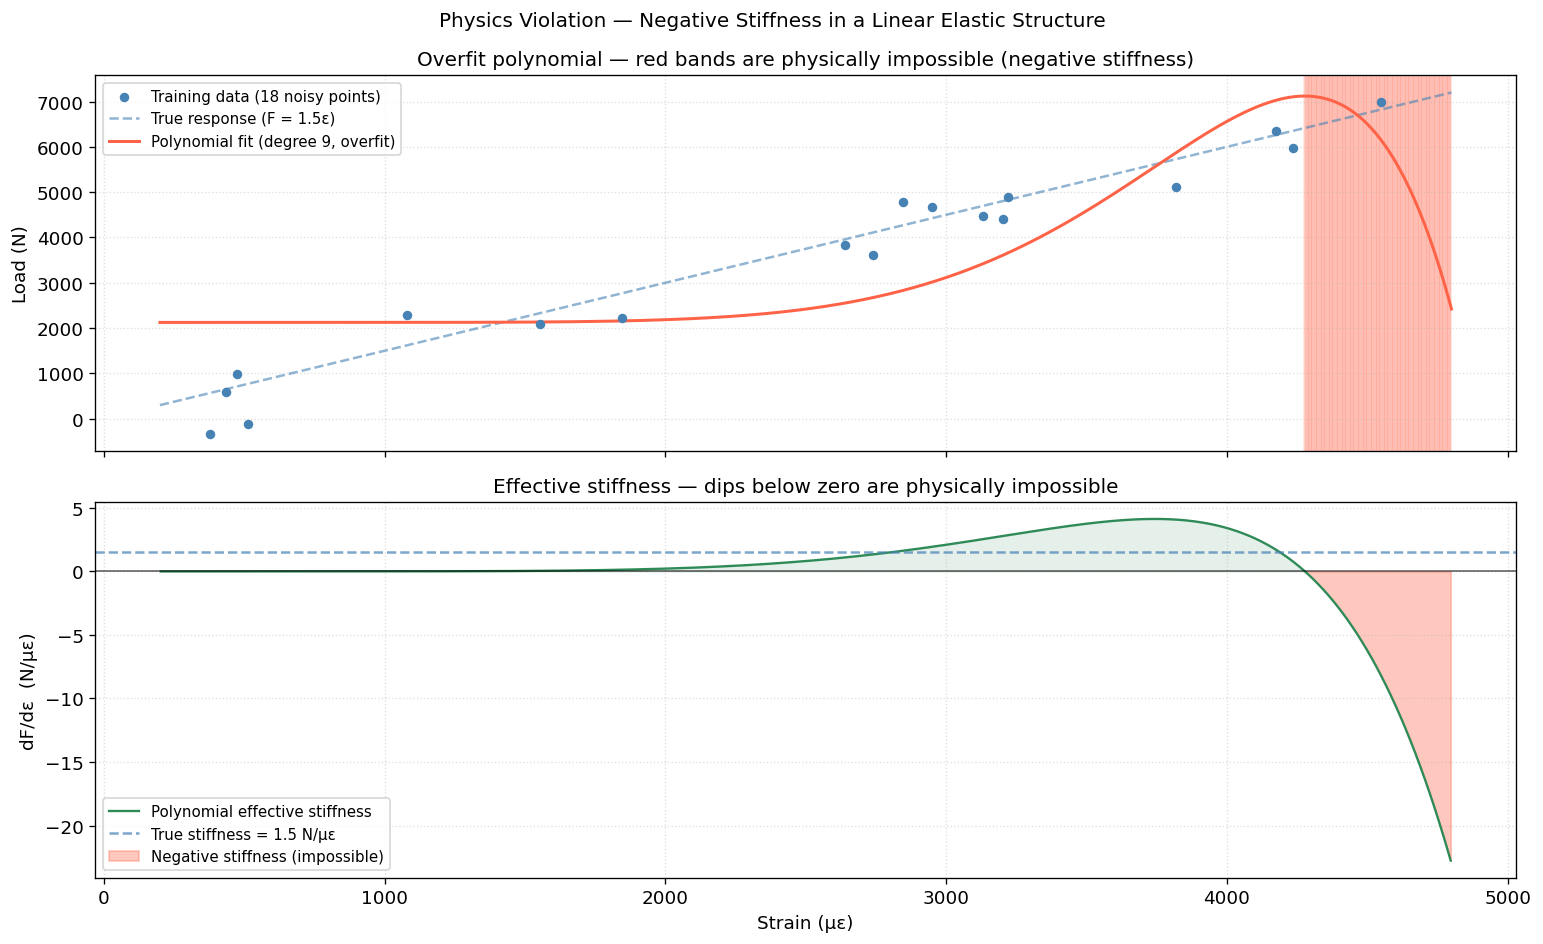

Negative-stiffness points: 91 / 799  (11.4%)

In a real elastic structure, stiffness is always positive.
These predictions are numerically valid outputs. Physically, they are impossible.
Nothing in the model flags this. The burden of detection falls on the engineer.


In [4]:
# ── 3. Physics Constraint Violations ─────────────────────────────────────────
# For a linear elastic structure, effective stiffness dF/dε is always positive.
# A degree-9 polynomial on 18 sparse noisy points has no awareness of this law.
# It chases noise between measurement locations, and its derivative goes negative
# in regions where consecutive data points happen to dip downward.
# (Imports live in the top cell.)

np.random.seed(17)
n_sparse    = 18
eps_sparse  = np.sort(np.random.uniform(200, 4800, n_sparse))
load_sparse = 1.5 * eps_sparse + np.random.normal(0, 500, n_sparse)

poly_over = Pipeline([
    ('poly', PolynomialFeatures(degree=9)),
    ('lr',   LinearRegression()),
])
poly_over.fit(eps_sparse.reshape(-1, 1), load_sparse)

eps_dense = np.linspace(200, 4800, 800)
pred_over = poly_over.predict(eps_dense.reshape(-1, 1))

stiffness  = np.diff(pred_over) / np.diff(eps_dense)
midpoints  = (eps_dense[:-1] + eps_dense[1:]) / 2
neg_mask   = stiffness < 0
true_stiff = 1.5  # N/µε — constant for a linear elastic spring

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Physics Violation — Negative Stiffness in a Linear Elastic Structure', fontsize=12)

axes[0].scatter(eps_sparse, load_sparse, s=22, color='steelblue', zorder=5,
                label=f'Training data ({n_sparse} noisy points)')
axes[0].plot(eps_dense, 1.5 * eps_dense, 'steelblue', lw=1.5, ls='--', alpha=0.6,
             label='True response (F = 1.5ε)')
axes[0].plot(eps_dense, pred_over, 'tomato', lw=1.8, label='Polynomial fit (degree 9, overfit)')
in_neg = np.where(neg_mask)[0]
for idx in in_neg:
    axes[0].axvspan(eps_dense[idx], eps_dense[idx+1], alpha=0.18, color='tomato')
axes[0].set_ylabel('Load (N)')
axes[0].set_title('Overfit polynomial — red bands are physically impossible (negative stiffness)')
axes[0].legend(fontsize=9); axes[0].grid(True, linestyle=':', alpha=0.4)

axes[1].plot(midpoints, stiffness, color='seagreen', lw=1.4, label='Polynomial effective stiffness')
axes[1].axhline(true_stiff, color='steelblue', lw=1.5, ls='--', alpha=0.7,
                label=f'True stiffness = {true_stiff} N/µε')
axes[1].axhline(0, color='black', lw=1.2, alpha=0.5)
axes[1].fill_between(midpoints, stiffness, 0,
                     where=neg_mask,  alpha=0.35, color='tomato', label='Negative stiffness (impossible)')
axes[1].fill_between(midpoints, stiffness, 0,
                     where=~neg_mask, alpha=0.12, color='seagreen')
axes[1].set_xlabel('Strain (µε)')
axes[1].set_ylabel('dF/dε  (N/µε)')
axes[1].set_title('Effective stiffness — dips below zero are physically impossible')
axes[1].legend(fontsize=9); axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig64_nb3_physics_violation.png', bbox_inches='tight', dpi=150)
plt.show()

n_neg = neg_mask.sum()
print(f"Negative-stiffness points: {n_neg} / {len(neg_mask)}  ({n_neg/len(neg_mask)*100:.1f}%)")
print()
print("In a real elastic structure, stiffness is always positive.")
print("These predictions are numerically valid outputs. Physically, they are impossible.")
print("Nothing in the model flags this. The burden of detection falls on the engineer.")

---
## 4 — Guardrails

The failure modes above share a common structure: the model does not know what it does not know. The solution is not to fix the model — it is to wrap the model in rules that encode what the model cannot know by itself.

Three lightweight guardrails are demonstrated below. Each is paired with the model that most clearly illustrates its mechanism. None require retraining.

- **Range blocking**: the linear model from §1 is used because it extrapolates without limit — the dashed line shows what would have been returned without the gate, and why that is dangerous  
- **Residual monitoring**: the neural network from §1 extrapolates approximately linearly; compared against the true physics model (which saturates at yield), the residual is near zero in the elastic zone and spikes sharply past yield — the alarm triggers reliably at the yield point  
- **Monotonicity enforcement**: a fresh degree-9 polynomial overfit to sparse elastic measurements oscillates between training points, driving effective stiffness negative; isotonic regression projects it onto the nearest monotone-increasing function — red shading marks the violations before correction  

None of these make the model smarter. They make the *system* safer.

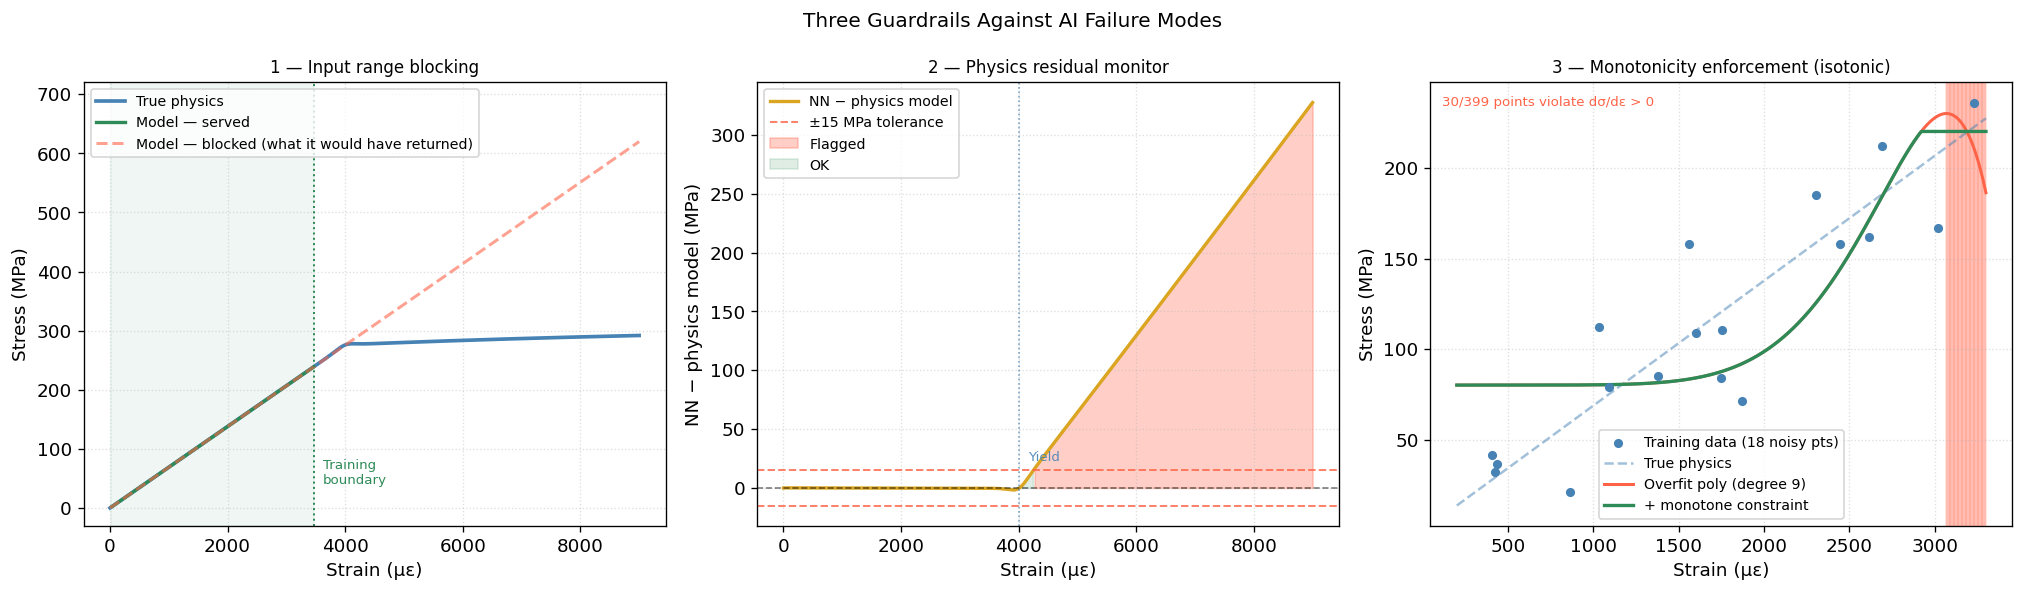

Guardrail 1 — Range blocking:    refuse predictions outside the training envelope
Guardrail 2 — Residual monitor:  flag divergence from a physics reference model
Guardrail 3 — Monotone clamp:    enforce dσ/dε ≥ 0 via isotonic regression

None of these require retraining. All can be wrapped around an existing model.
The engineer sets the rules; the model operates within them.


In [5]:
# ── 4. Guardrails — Practical Mitigations ────────────────────────────────────
# Reuses the linear model (lin) and neural network (nn) fit in §1.
# (Imports live in the top cell.)
eps_eval = np.linspace(0, 9000, 300)
lin_raw  = lin.predict(eps_eval.reshape(-1, 1))   # panel 1: linear model
nn_raw   = nn.predict(eps_eval.reshape(-1, 1))    # panel 2: NN

# ── Guardrail 1: Input range blocking ─────────────────────────────────────────
# Linear model extrapolates without limit — makes the case for blocking obvious.
eps_lo, eps_hi = eps_tr.min(), eps_tr.max()
in_range = (eps_eval >= eps_lo) & (eps_eval <= eps_hi)

# ── Guardrail 2: Physics residual monitor ─────────────────────────────────────
# NN extrapolates approximately linearly.  Compare against the physics model
# (which saturates at yield).  In the elastic zone residual ≈ 0; past yield
# the NN overshoots and the residual spikes above tolerance.
physics_ref = al_stress(eps_eval)
residual    = nn_raw - physics_ref
tol = 15   # MPa — acceptable deviation from physics reference

# ── Guardrail 3: Monotonicity enforcement ─────────────────────────────────────
# Degree-9 polynomial overfit to 18 sparse noisy elastic measurements.
# Its derivative goes negative in several regions (Runge's phenomenon).
# Isotonic regression eliminates those violations without retraining.
np.random.seed(7)
n_p3   = 18
eps_p3 = np.sort(np.random.uniform(200, 3300, n_p3))
sig_p3 = al_stress(eps_p3) + np.random.normal(0, 25, n_p3)
poly_p3 = Pipeline([('poly', PolynomialFeatures(9)), ('lr', LinearRegression())])
poly_p3.fit(eps_p3.reshape(-1, 1), sig_p3)
eps_p3_ev    = np.linspace(200, 3300, 400)
pred_p3      = poly_p3.predict(eps_p3_ev.reshape(-1, 1))
pred_p3_mono = IsotonicRegression(increasing=True).fit_transform(eps_p3_ev, pred_p3)
stiff_p3     = np.diff(pred_p3) / np.diff(eps_p3_ev)
neg_p3       = stiff_p3 < 0

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Three Guardrails Against AI Failure Modes', fontsize=12)

# Panel 1 — range blocking ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(eps_eval, al_stress(eps_eval), 'steelblue', lw=2.2, label='True physics')
ax.plot(eps_eval[in_range],  lin_raw[in_range],  'seagreen', lw=2,
        label='Model — served')
ax.plot(eps_eval[~in_range], lin_raw[~in_range], 'tomato', lw=1.8, ls='--', alpha=0.6,
        label='Model — blocked (what it would have returned)')
ax.axvspan(eps_lo, eps_hi, alpha=0.07, color='seagreen')
ax.axvline(eps_hi, color='seagreen', lw=1.2, ls=':')
ax.text(eps_hi + 150, 40, 'Training\nboundary', fontsize=8, color='seagreen')
ax.set_xlabel('Strain (µε)'); ax.set_ylabel('Stress (MPa)')
ax.set_title('1 — Input range blocking', fontsize=10)
ax.set_ylim(-30, 720)
ax.legend(fontsize=8.5); ax.grid(True, linestyle=':', alpha=0.4)

# Panel 2 — physics residual monitor ──────────────────────────────────────────
ax = axes[1]
ax.plot(eps_eval, residual, color='goldenrod', lw=2, label='NN − physics model')
ax.axhline(0,    color='black',  lw=1,   ls='--', alpha=0.5)
ax.axhline( tol, color='tomato', lw=1.2, ls='--', alpha=0.8)
ax.axhline(-tol, color='tomato', lw=1.2, ls='--', alpha=0.8, label=f'±{tol} MPa tolerance')
ax.fill_between(eps_eval, residual, 0,
                where=np.abs(residual) > tol, alpha=0.30, color='tomato', label='Flagged')
ax.fill_between(eps_eval, residual, 0,
                where=np.abs(residual) <= tol, alpha=0.15, color='seagreen', label='OK')
ax.axvline(eps_y_ue, color='steelblue', lw=1, ls=':', alpha=0.7)
ax.text(eps_y_ue + 150, tol + 8, 'Yield', fontsize=8, color='steelblue', alpha=0.9)
ax.set_xlabel('Strain (µε)'); ax.set_ylabel('NN − physics model (MPa)')
ax.set_title('2 — Physics residual monitor', fontsize=10)
ax.legend(fontsize=8.5); ax.grid(True, linestyle=':', alpha=0.4)

# Panel 3 — monotonicity enforcement ──────────────────────────────────────────
ax = axes[2]
ax.scatter(eps_p3, sig_p3, s=20, color='steelblue', zorder=5,
           label=f'Training data ({n_p3} noisy pts)')
ax.plot(eps_p3_ev, al_stress(eps_p3_ev), 'steelblue', lw=1.5, ls='--', alpha=0.5,
        label='True physics')
ax.plot(eps_p3_ev, pred_p3,      'tomato',   lw=1.8, label='Overfit poly (degree 9)')
ax.plot(eps_p3_ev, pred_p3_mono, 'seagreen', lw=2.0, label='+ monotone constraint')
for idx in np.where(neg_p3)[0]:
    ax.axvspan(eps_p3_ev[idx], eps_p3_ev[idx+1], alpha=0.18, color='tomato')
n_neg_p3 = neg_p3.sum()
ax.text(0.02, 0.97, f'{n_neg_p3}/{len(neg_p3)} points violate dσ/dε > 0',
        transform=ax.transAxes, fontsize=8, va='top', color='tomato')
ax.set_xlabel('Strain (µε)'); ax.set_ylabel('Stress (MPa)')
ax.set_title('3 — Monotonicity enforcement (isotonic)', fontsize=10)
ax.legend(fontsize=8.5); ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig64_nb4_ai_guardrails.png', bbox_inches='tight', dpi=150)
plt.show()

print("Guardrail 1 — Range blocking:    refuse predictions outside the training envelope")
print("Guardrail 2 — Residual monitor:  flag divergence from a physics reference model")
print("Guardrail 3 — Monotone clamp:    enforce dσ/dε ≥ 0 via isotonic regression")
print()
print("None of these require retraining. All can be wrapped around an existing model.")
print("The engineer sets the rules; the model operates within them.")

---
## Where to take this next

These four demonstrations are deliberately minimal — each is a starting point you can extend toward a real deployment.

- **Turn the guardrails into a wrapper class.** Fold the range block, residual monitor, and monotone clamp from §4 into a single `GuardedRegressor` that wraps any fitted estimator and returns a prediction *plus* a status flag (`served` / `blocked` / `flagged`), logging every out-of-envelope request. That log is the raw material for the input-domain monitoring discussed in Chapter 60.
- **Add a calibrated uncertainty estimate.** Replace the point predictions in §1 with a bootstrap ensemble or quantile model, and test whether the predicted intervals actually widen past yield. A trustworthy model should at least be *uncertain* where it is wrong — check whether yours is.
- **Make the distribution-shift alarm automatic.** In §2 the failure was only visible because we had aluminium labels to compare against — which we would not have in the field. Fit an unsupervised detector on the steel training features alone (a Mahalanobis distance or an isolation forest) and confirm it flags the aluminium inputs *before* any stress is predicted.